In [1]:
import sys, os
import numpy as np
import time
import math
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
import matplotlib.pyplot as plt
import cv2
import numpy as np
import color_seg_utils as seg
# %matplotlib widget
%load_ext autoreload
%autoreload 2


In [26]:
# data_path = "/home/zfei/codes/data/upi/rs435i_2024-08-22-09-17-13/"
data_path = "/home/zfei/data/UPI/rs435i_2024-08-22-09-17-13/"
color_img_idx = 20
color_img_path = os.path.join(data_path, f"color_{color_img_idx:06d}.png")
color_img = cv2.cvtColor(cv2.imread(color_img_path), cv2.COLOR_BGR2RGB)

print(color_img_path)


/home/zfei/data/UPI/rs435i_2024-08-22-09-17-13/color_000020.png


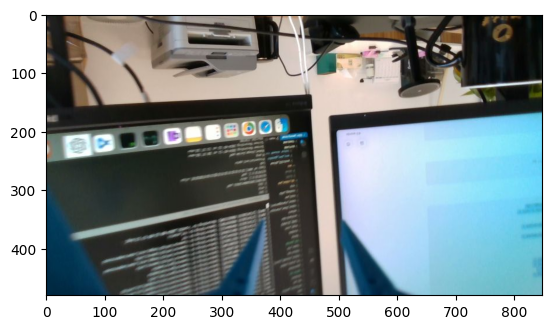

In [27]:
plt.imshow(color_img)

roi_mean [ 15.1509434   61.70849057  90.9990566  101.65283019 224.36698113
  90.9990566 ]
roi_std [23.3804032  26.70292408 29.6116531   1.05071472 37.79033824 29.6116531 ]


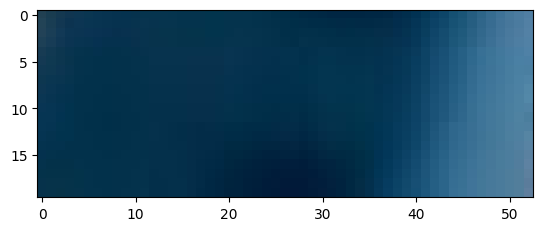

In [83]:
roi = color_img[460:480,300:353, :]
roi_mean, roi_std =  seg.get_center_std(roi)
print("roi_mean", roi_mean)
print("roi_std", roi_std)
plt.imshow(roi)

In [177]:

color_img_idx = 143
color_img_path = os.path.join(data_path, f"color_{color_img_idx:06d}.png")
color_img = cv2.cvtColor(cv2.imread(color_img_path), cv2.COLOR_BGR2RGB)


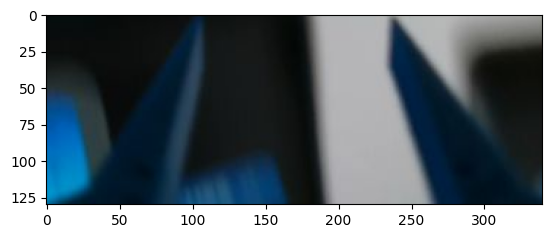

In [178]:
gripper_part = color_img[350:480, 270:610, :]
plt.imshow(gripper_part)

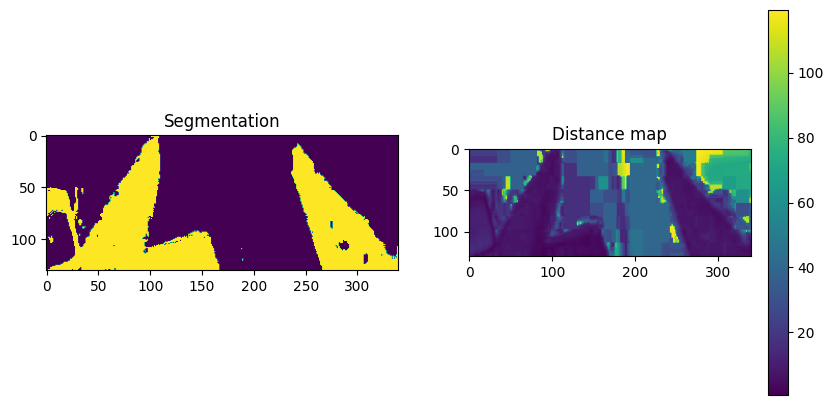

In [179]:
threshold = 10
segmentation, distance_map = seg.segment(gripper_part, roi_mean, roi_std, threshold, var_weighting=False)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(segmentation)
axs[0].set_title("Segmentation")
axs[1].imshow(distance_map)
axs[1].set_title("Distance map")
# add colorbar
plt.colorbar(axs[1].imshow(distance_map), ax=axs[1])

openess 0.641764705882353


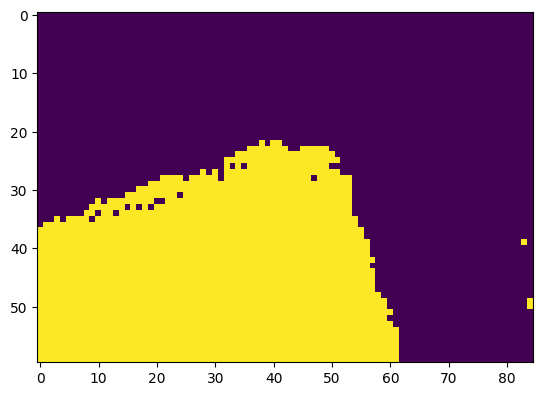

In [180]:
open_detect_area = segmentation[70:,105:190]
openess = 1 - open_detect_area.sum() / open_detect_area.size
print("openess", openess)
plt.imshow(open_detect_area)

In [158]:
def detect_openess(image, gripper_region, open_detect_region, roi_mean, roi_std, threshold, plot=False):
    gripper_part = image[gripper_region[0]:gripper_region[1], gripper_region[2]:gripper_region[3]]
    segmentation, distance_map = seg.segment(gripper_part, roi_mean, roi_std, threshold, var_weighting=False)
    segmentation_full = np.zeros([image.shape[0], image.shape[1]]) 
    segmentation_full[gripper_region[0]:gripper_region[1], gripper_region[2]:gripper_region[3]] = segmentation
    open_detect_area = segmentation_full[open_detect_region[0]:open_detect_region[1], open_detect_region[2]:open_detect_region[3]]
    openess = 1 - open_detect_area.sum() / open_detect_area.size
    plot_img = None
    if plot:
        plot_img = np.stack([segmentation_full, segmentation_full, segmentation_full], axis=2) * 255
        plot_img = plot_img.astype(np.uint8)
        cv2.rectangle(plot_img, (gripper_region[2], gripper_region[0]), (gripper_region[3], gripper_region[1]), (0, 255, 0), 2)
        cv2.rectangle(plot_img, (open_detect_region[2], open_detect_region[0]), (open_detect_region[3], open_detect_region[1]), (0, 0, 255), 2)
        # add text of openness
        cv2.putText(plot_img, f"openess: {openess:.2f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
        
    
    return openess, plot_img

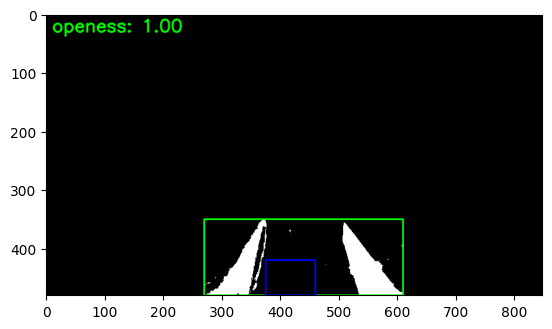

In [165]:
gripper_region = [350, 480, 270, 610]
open_detect_region = [420, 480, 375, 460]
roi_mean = np.asarray([15.01226415, 61.08584906, 91.47264151, 102.03396226, 224.51509434, 91.47264151])
roi_std = np.asarray([22.88030463, 26.93516303, 29.38851988, 1.07316203, 36.84640171, 29.38851988])
threshold = 10

openesss = []
for color_img_idx in range(0, 179):
    color_img_path = os.path.join(data_path, f"color_{color_img_idx:06d}.png")
    color_img = cv2.cvtColor(cv2.imread(color_img_path), cv2.COLOR_BGR2RGB)
    openess, plot_img = detect_openess(color_img, gripper_region, open_detect_region, roi_mean, roi_std, threshold, plot=True)
    openesss.append(openess)
    plt.imshow(plot_img)
    cv2.imwrite(f"./temp/openess_{color_img_idx:06d}.png", plot_img)

In [103]:
gripper_region = [350, 480, 270, 610]
open_detect_region = [70, 480, 105, 190]
roi_mean = np.asarray([15.01226415, 61.08584906, 91.47264151, 102.03396226, 224.51509434, 91.47264151])
roi_std = np.asarray([22.88030463, 26.93516303, 29.38851988, 1.07316203, 36.84640171, 29.38851988])
threshold = 20

openesss = []
for color_img_idx in range(0, 179):
    color_img_path = os.path.join(data_path, f"color_{color_img_idx:06d}.png")
    color_img = cv2.cvtColor(cv2.imread(color_img_path), cv2.COLOR_BGR2RGB)
    openess = detect_openess(color_img, gripper_region, open_detect_region, roi_mean, roi_std, threshold)
    openesss.append(openess)


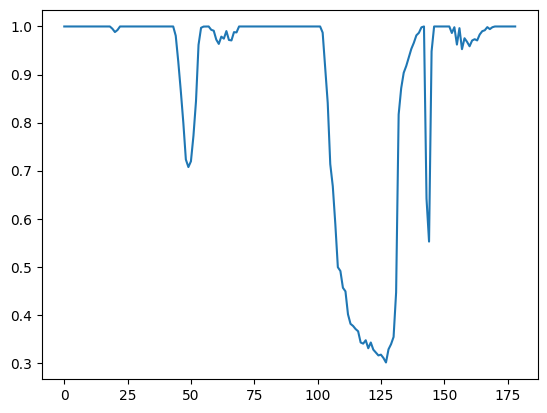

In [166]:
plt.plot(openesss)

In [ ]:
gripper_region = [350, 480, 270, 610]
roi_mean = np.asarray([15.01226415, 61.08584906, 91.47264151, 102.03396226, 224.51509434, 91.47264151])
roi_std = np.asarray([22.88030463, 26.93516303, 29.38851988, 1.07316203, 36.84640171, 29.38851988])
threshold = 20

openesss = []
for color_img_idx in range(0, 179):
    color_img_path = os.path.join(data_path, f"color_{color_img_idx:06d}.png")
    color_img = cv2.cvtColor(cv2.imread(color_img_path), cv2.COLOR_BGR2RGB)
    openess = detect_openess(color_img, gripper_region, roi_mean, roi_std, threshold)
    openesss.append(openess)
